In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

# Dataset generation function
def generate_data(n_samples=2500):
    ages = np.random.randint(18, 65, size=n_samples)
    genders = np.random.choice(['Male', 'Female', 'Other'], size=n_samples, p=[0.48, 0.48, 0.04])
    device_types = np.random.choice(['Mobile', 'Desktop', 'Tablet'], size=n_samples, p=[0.55, 0.35, 0.10])
    traffic_sources = np.random.choice(['Organic Search', 'Social Media', 'Direct', 'Email', 'Paid Ads'], size=n_samples)
    
    pages_viewed = np.random.poisson(lam=6, size=n_samples) + 1
    time_on_site = pages_viewed * np.random.uniform(20, 90, size=n_samples)
    cart_items = np.random.binomial(n=5, p=0.3, size=n_samples)
    previous_purchases = np.random.poisson(lam=2, size=n_samples)
    discount_used = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
    days_since_last_visit = np.random.randint(0, 60, size=n_samples)
    
    # Mathematical logic for Purchase probability
    logit = (-3.5 + 0.45 * cart_items + 0.005 * time_on_site + 
             0.15 * previous_purchases + 0.5 * discount_used - 0.03 * days_since_last_visit)
    prob = 1 / (1 + np.exp(-logit))
    purchase = np.random.binomial(1, prob)

    df = pd.DataFrame({
        'CustomerID': [f"CUST_{10000 + i}" for i in range(n_samples)],
        'Age': ages,
        'Gender': genders,
        'DeviceType': device_types,
        'TrafficSource': traffic_sources,
        'PagesViewed': pages_viewed,
        'TimeOnSite': np.round(time_on_site, 2),
        'CartItems': cart_items,
        'PreviousPurchases': previous_purchases,
        'DiscountUsed': discount_used,
        'DaysSinceLastVisit': days_since_last_visit,
        'Purchase': purchase
    })
    
    # Introducing small missing values for cleaning
    df.loc[df.sample(frac=0.02, random_state=42).index, 'Age'] = np.nan
    df.loc[df.sample(frac=0.01, random_state=42).index, 'DeviceType'] = np.nan
    return df

df = generate_data(2500)
print("Data Shape:", df.shape)
df.head()

Data Shape: (2500, 12)


,CustomerID,Age,Gender,DeviceType,TrafficSource,PagesViewed,TimeOnSite,CartItems,PreviousPurchases,DiscountUsed,DaysSinceLastVisit,Purchase
0,CUST_10000,56.0,Female,Mobile,Email,5,276.16,0,2,0,4,0
1,CUST_10001,46.0,Female,Desktop,Direct,9,657.43,1,4,0,56,0
2,CUST_10002,32.0,Female,Mobile,Organic Search,4,189.79,1,2,0,44,0
3,CUST_10003,60.0,Male,Mobile,Social Media,5,215.71,2,1,0,48,0
4,CUST_10004,25.0,Female,Mobile,Organic Search,7,545.17,2,0,0,9,1


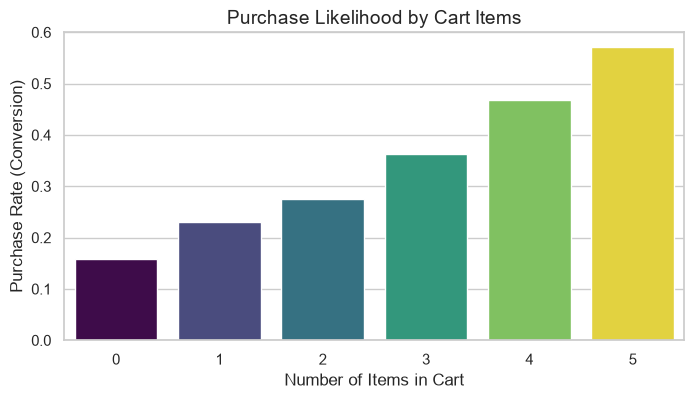

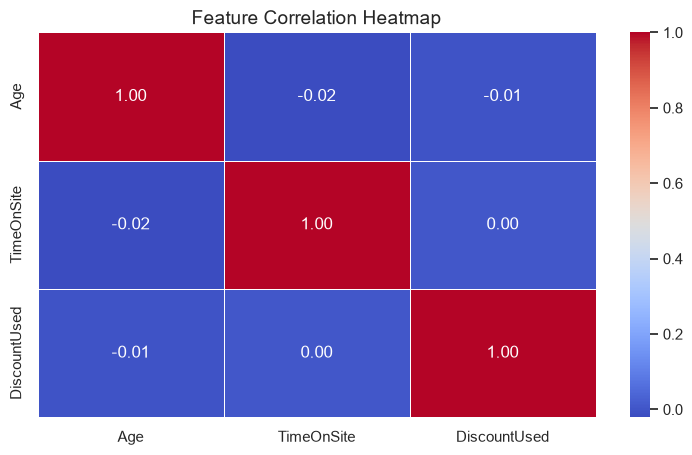

In [4]:
# Graph 1: Cart Items vs Purchase Rate
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='CartItems', y='Purchase', hue='CartItems', palette='viridis', errorbar=None, legend=False)
plt.title('Purchase Likelihood by Cart Items', fontsize=14)
plt.xlabel('Number of Items in Cart')
plt.ylabel('Purchase Rate (Conversion)')
plt.show()

# Graph 2: Correlation Heatmap
plt.figure(figsize=(9, 5))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Drop Identifier & Separate Target
X = df.drop(columns=['CustomerID', 'Purchase'])
y = df['Purchase']

# 2. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Identify numerical & categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

# 3. Create Preprocessing Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# 4. Train & Evaluate Baseline Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 4)
    })

baseline_comparison = pd.DataFrame(results)
print("=== BASELINE MODEL PERFORMANCE COMPARISON ===")
baseline_comparison

=== BASELINE MODEL PERFORMANCE COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.786,0.6667,0.3281,0.4398,0.7613
1,Decision Tree,0.718,0.4519,0.4766,0.4639,0.6388
2,Random Forest,0.734,0.4719,0.3281,0.3871,0.6905


=== OPTIMIZED RANDOM FOREST PERFORMANCE ===
Best Hyperparameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Optimized F1-Score: 0.5414
Optimized ROC-AUC:  0.7542



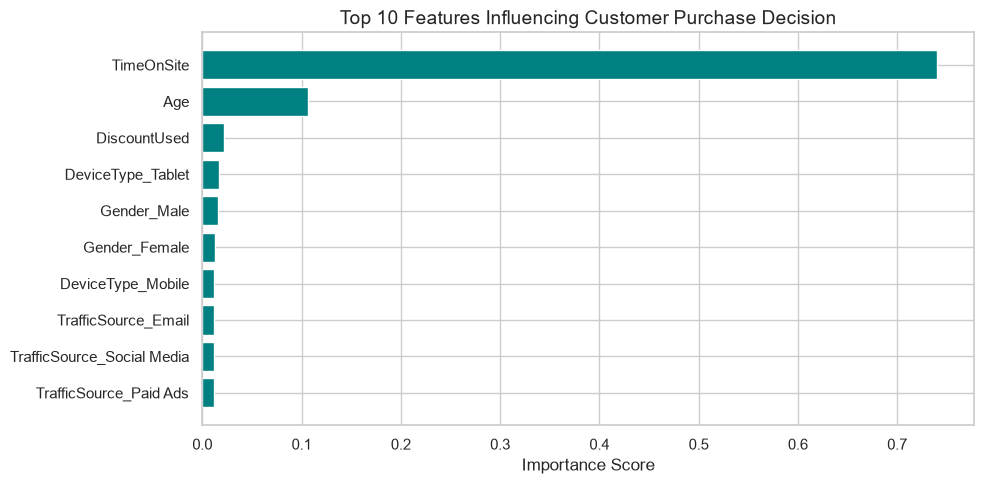

In [7]:
from sklearn.model_selection import GridSearchCV

# 1. Pipeline and Hyperparameter Tuning using GridSearchCV
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Parameter Grid for Random Forest
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced']  # Class imbalance fix karne ke liye
}

grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best Model Extraction
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)
best_probs = best_model.predict_proba(X_test)[:, 1]

print("=== OPTIMIZED RANDOM FOREST PERFORMANCE ===")
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Optimized F1-Score: {f1_score(y_test, best_preds):.4f}")
print(f"Optimized ROC-AUC:  {roc_auc_score(y_test, best_probs):.4f}\n")

# 2. Feature Importance Extraction
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + encoded_cat_cols

importances = best_model.named_steps['classifier'].feature_importances_

feature_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot Top 10 Feature Importance Chart
plt.figure(figsize=(10, 5))
top_10 = feature_df.head(10).sort_values(by='Importance', ascending=True)
plt.barh(top_10['Feature'], top_10['Importance'], color='teal')
plt.title('Top 10 Features Influencing Customer Purchase Decision', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

=== PERFORMANCE AT ADJUSTED THRESHOLD (0.4) ===
Adjusted Precision: 0.3991
Adjusted Recall:    0.7266
Adjusted F1-Score:  0.5152

=== CUSTOMER SEGMENTATION DISTRIBUTION (TEST SET) ===
Medium Likelihood (Warm)    328
Low Likelihood (Cold)       126
High Likelihood (Hot)        46
Name: count, dtype: int64




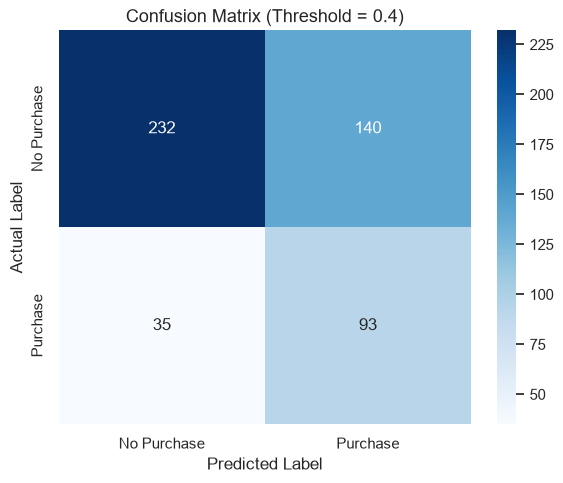

In [9]:
from sklearn.metrics import confusion_matrix

# 1. Custom Threshold Tuning (0.40 Probability Cutoff)
custom_threshold = 0.40
adjusted_preds = (best_probs >= custom_threshold).astype(int)

print(f"=== PERFORMANCE AT ADJUSTED THRESHOLD ({custom_threshold}) ===")
print(f"Adjusted Precision: {precision_score(y_test, adjusted_preds):.4f}")
print(f"Adjusted Recall:    {recall_score(y_test, adjusted_preds):.4f}")
print(f"Adjusted F1-Score:  {f1_score(y_test, adjusted_preds):.4f}\n")

# 2. Customer Purchase-Likelihood Segmentation
def categorize_customer(prob):
    if prob >= 0.70:
        return 'High Likelihood (Hot)'
    elif prob >= 0.35:
        return 'Medium Likelihood (Warm)'
    else:
        return 'Low Likelihood (Cold)'

customer_segments = pd.Series(best_probs).apply(categorize_customer)

print("=== CUSTOMER SEGMENTATION DISTRIBUTION (TEST SET) ===")
print(customer_segments.value_counts())
print("\n" + "="*50 + "\n")

# 3. Confusion Matrix Visualization Plot
cm = confusion_matrix(y_test, adjusted_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.title(f'Confusion Matrix (Threshold = {custom_threshold})', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()